In [2]:
import pandas as pd
import numpy as np
from pathlib import Path

# 1. LOAD DATA AND DEFINE PATHS
INPUT_FILE = '../output/dataset_no0min.csv'
ENHANCED_FEATURES_OUT = '../output/forecaster_pro/fpl_features_augmented.csv'

df = pd.read_csv(INPUT_FILE)

def enrich_features_v2(df):
    """
    Advanced enrichment for Version 2:
    - Availability Logic: Rolling average minutes.
    - Fixture Context: Shifting opponent data.
    - Seasonality: Seasonal phases.
    - Team Influence: Calculating point share dynamically.
    """
    # Ensure strict chronological order
    df = df.sort_values(['Player UUID', 'season', 'Gameweek'])
    
    # A. AVAILABILITY FEATURE (Level Prediction)
    df['Rolling_Avg_Minutes_5'] = df.groupby('Player UUID')['Minutes Played'].transform(
        lambda x: x.shift(1).rolling(5, min_periods=1).mean()
    ).fillna(0)

    # B. TARGET CONTEXT (Fixture Impact - No Leakage)
    df['Next_Opponent_Difficulty'] = df.groupby(['Player UUID', 'season'])['Opponent Difficulty'].shift(-1)
    df['Next_Is_Home'] = df.groupby(['Player UUID', 'season'])['Is Home'].shift(-1)
    
    # C. SEASONALITY
    df['Season_Phase'] = pd.cut(df['Gameweek'], 
                                bins=[0, 10, 19, 29, 38], 
                                labels=[1, 2, 3, 4]).astype(float)
    
    # D. TEAM POINT SHARE (Flexible column detection)
    # Detect the correct team column name
    team_col = None
    for col in ['Player Team ID', 'team', 'Player Team Name']:
        if col in df.columns:
            team_col = col
            break
    
    if team_col:
        team_gw_totals = df.groupby([team_col, 'season', 'Gameweek'])['Total Points'].transform('sum')
        df['Team_Point_Share'] = (df['Total Points'] / team_gw_totals).replace([np.inf, -np.inf], 0).fillna(0)
    else:
        print("Warning: No team column found. Skipping Team_Point_Share calculation.")
        df['Team_Point_Share'] = 0

    # Return the dataframe and drop rows missing the 'Next' match info
    return df.dropna(subset=['Next_Opponent_Difficulty'])

print(f"Processing {len(df):,} rows from {INPUT_FILE}...")
df_augmented = enrich_features_v2(df)

output_path = Path(ENHANCED_FEATURES_OUT)
output_path.parent.mkdir(parents=True, exist_ok=True)

# Save the augmented file
df_augmented.to_csv(ENHANCED_FEATURES_OUT, index=False, encoding='utf-8-sig')

print(f"Enhanced dataset created: {ENHANCED_FEATURES_OUT}")
print(f"New Shape: {df_augmented.shape[0]} rows and {df_augmented.shape[1]} columns.")

# Sanity check display
display(df_augmented[['Player Name', 'season', 'Gameweek', 'Next_Opponent_Difficulty', 'Rolling_Avg_Minutes_5', 'Team_Point_Share']].head())

Processing 68,905 rows from ../output/dataset_no0min.csv...
Enhanced dataset created: ../output/forecaster_pro/fpl_features_augmented.csv
New Shape: 65641 rows and 47 columns.


,Player Name,season,Gameweek,Next_Opponent_Difficulty,Rolling_Avg_Minutes_5,Team_Point_Share
31970,Joachim Andersen,2020-21,7,4.0,0.0,0.090909
31971,Joachim Andersen,2020-21,8,4.0,90.0,0.090909
31972,Joachim Andersen,2020-21,9,4.0,90.0,0.033333
31973,Joachim Andersen,2020-21,10,5.0,90.0,0.042553
31974,Joachim Andersen,2020-21,11,4.0,90.0,0.047619


## Cell 2: Augmented Window Generation (Context-Aware)

In [3]:
import pandas as pd
import numpy as np
from pathlib import Path

# 1. SETUP PROFESSIONAL FOLDER STRUCTURE
PRO_OUTPUT_DIR = Path('../output/forecaster_pro')
PRO_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def generate_fpl_windows_pro(df, window_size=6):
    train_data = []
    uuid_col = 'Player UUID'
    
    # Ensure chronological order
    df = df.sort_values([uuid_col, 'season', 'Gameweek'])
    
    # Group by player to prevent data from "bleeding" between different players
    for pid, group in df.groupby(uuid_col):
        points = group['Total Points'].values
        
        # TARGET CONTEXT: These are the features for the match we want to predict
        # They were prepared in Cell 1 using the shift(-1) logic
        next_diff = group['Next_Opponent_Difficulty'].values
        next_home = group['Next_Is_Home'].values
        avg_min = group['Rolling_Avg_Minutes_5'].values
        phase = group['Season_Phase'].values
        
        if len(points) <= window_size:
            continue
            
        position = group['Position'].iloc[0] 
        
        for i in range(len(points) - window_size):
            # 1. THE PAST: The 6-week "Form" window (Lags)
            window = points[i : i + window_size]
            
            # 2. THE FUTURE: Context of the match we are trying to predict
            # We take this from the index [i + window_size - 1] because that row 
            # holds the "Next" fixture info for the upcoming target game.
            target_diff = next_diff[i + window_size - 1] 
            target_home = next_home[i + window_size - 1]
            target_min = avg_min[i + window_size - 1]
            target_phase = phase[i + window_size - 1]
            
            # 3. THE TARGET: What actually happened in that match
            target_points = points[i + window_size]
            
            # RULE: Skip windows where the player is a "ghost" (0 points for 6 weeks + 0 in target)
            if np.all(window == 0) and target_points == 0:
                continue
                
            # Create the data row
            row = list(window) + [position, target_diff, target_home, target_min, target_phase, target_points]
            train_data.append(row)
            
    # Professional Column Names
    columns = [f'lag_{i}' for i in range(window_size, 0, -1)] + \
              ['position', 'next_difficulty', 'next_is_home', 'rolling_min', 'season_phase', 'target']
              
    return pd.DataFrame(train_data, columns=columns)

# Execute the Pro window generation
windowed_df = generate_fpl_windows_pro(df_augmented)

# Convert categorical columns
windowed_df['position'] = windowed_df['position'].astype('category')

# Save this intermediate feature set to our new Pro folder
WINDOWED_FEATURES_PATH = PRO_OUTPUT_DIR / 'fpl_windowed_features_pro.csv'
windowed_df.to_csv(WINDOWED_FEATURES_PATH, index=False)

print(f" Pro Windowed dataset created: {WINDOWED_FEATURES_PATH}")
print(f" Total Training Windows: {windowed_df.shape[0]}")
display(windowed_df.head())

 Pro Windowed dataset created: ..\output\forecaster_pro\fpl_windowed_features_pro.csv
 Total Training Windows: 58330


,lag_6,lag_5,lag_4,lag_3,lag_2,lag_1,position,next_difficulty,next_is_home,rolling_min,season_phase,target
0,6,2,1,2,1,1,DEF,3.0,True,90.0,2.0,8
1,2,1,2,1,1,8,DEF,2.0,False,90.0,2.0,-1
2,1,2,1,1,8,-1,DEF,2.0,True,90.0,2.0,6
3,2,1,1,8,-1,6,DEF,4.0,False,84.2,2.0,1
4,1,1,8,-1,6,1,DEF,4.0,True,84.2,2.0,2


## Cell 3: Data Splitting and Scaling (Comparison Setup)

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import joblib

# 1. DEFINE FEATURES AND TARGET
# We include our new context features in the training
X = windowed_df.drop(columns=['target'])
y = windowed_df['target']

# 2. CHRONOLOGICAL SPLIT (The 5-6 Week Strategy)
# Using 85% for training and 15% for recent validation
split_index = int(len(windowed_df) * 0.85)

X_train_raw = X.iloc[:split_index]
X_val_raw = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_val = y.iloc[split_index:]

# 3. IDENTIFY NUMERIC VS CATEGORICAL
# We scale the lags, difficulty, and minutes, but NOT the position or is_home
numeric_cols = [c for c in X.columns if 'lag' in c or 'difficulty' in c or 'min' in c or 'phase' in c]

# 4. PATH A: SCALED VERSION
scaler = StandardScaler()

X_train_scaled = X_train_raw.copy()
X_train_scaled[numeric_cols] = scaler.fit_transform(X_train_raw[numeric_cols])

X_val_scaled = X_val_raw.copy()
X_val_scaled[numeric_cols] = scaler.transform(X_val_raw[numeric_cols])

# 5. SAVE SCALER FOR LATER USE
SCALER_PATH = PRO_OUTPUT_DIR / 'fpl_pro_scaler.pkl'
joblib.dump(scaler, SCALER_PATH)

print(f"Split complete at index {split_index}")
print(f"Training size: {len(X_train_raw)} | Validation size: {len(X_val_raw)}")
print(f"Scaler saved to: {SCALER_PATH}")
print(f"Features being compared: {list(X.columns)}")

Split complete at index 49580
Training size: 49580 | Validation size: 8750
Scaler saved to: ..\output\forecaster_pro\fpl_pro_scaler.pkl
Features being compared: ['lag_6', 'lag_5', 'lag_4', 'lag_3', 'lag_2', 'lag_1', 'position', 'next_difficulty', 'next_is_home', 'rolling_min', 'season_phase']


## Cell 4: Parallel Training & Performance Comparison for scaled and unscaled model

In [5]:
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import pandas as pd

# 1. SETUP PARAMETERS (Shared for both models)
lgbm_params = {
    'n_estimators': 1500,
    'learning_rate': 0.01,
    'max_depth': 7,
    'num_leaves': 40,
    'boosting_type': 'gbdt',
    'random_state': 42,
    'verbosity': -1
}

# 2. TRAIN MODEL A: THE RAW VERSION
print(" Training RAW Model (No Scaling)...")
model_raw = lgb.LGBMRegressor(**lgbm_params)
model_raw.fit(
    X_train_raw, y_train,
    eval_set=[(X_val_raw, y_val)],
    categorical_feature=['position', 'next_is_home'],
    callbacks=[lgb.early_stopping(stopping_rounds=100)]
)

# 3. TRAIN MODEL B: THE SCALED VERSION
print("\n Training SCALED Model (StandardScaler)...")
model_scaled = lgb.LGBMRegressor(**lgbm_params)
model_scaled.fit(
    X_train_scaled, y_train,
    eval_set=[(X_val_scaled, y_val)],
    categorical_feature=['position', 'next_is_home'],
    callbacks=[lgb.early_stopping(stopping_rounds=100)]
)

# 4. PREDICTIONS & METRICS
preds_raw = model_raw.predict(X_val_raw)
preds_scaled = model_scaled.predict(X_val_scaled)

results_comparison = {
    'Metric': ['MAE', 'RMSE'],
    'Raw Model': [
        mean_absolute_error(y_val, preds_raw),
        np.sqrt(mean_squared_error(y_val, preds_raw))
    ],
    'Scaled Model': [
        mean_absolute_error(y_val, preds_scaled),
        np.sqrt(mean_squared_error(y_val, preds_scaled))
    ]
}

# 5. DISPLAY RESULTS
df_metrics = pd.DataFrame(results_comparison)
print("\n--- Final Performance Comparison ---")
display(df_metrics)

# 6. SAVE THE WINNER
# Usually, they will be very close, but let's save both for safety
model_raw.booster_.save_model(str(PRO_OUTPUT_DIR / 'fpl_pro_model_raw.txt'))
model_scaled.booster_.save_model(str(PRO_OUTPUT_DIR / 'fpl_pro_model_scaled.txt'))

 Training RAW Model (No Scaling)...
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[376]	valid_0's l2: 8.40956

 Training SCALED Model (StandardScaler)...
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[427]	valid_0's l2: 8.41137

--- Final Performance Comparison ---


,Metric,Raw Model,Scaled Model
0,MAE,2.120008,2.119818
1,RMSE,2.899925,2.900236


notes on scaled and unscaled 
* MAE: The Scaled Model is better by only 0.00019 points. 
* RMSE: The Raw Model is actually slightly better here.

So, LightGBM does not care about your scaling?  

## Cell 5: The "Top Performer" Error Analysis (calculating MAE specifically for the high-scorers)

Overall Validation MAE: 2.1200
MAE for Top Performers (8+ pts): 6.6781


C:\Users\skourako\AppData\Local\Temp\ipykernel_13480\2307696981.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance (%)', y='Feature', data=feat_imp_df, palette='viridis')


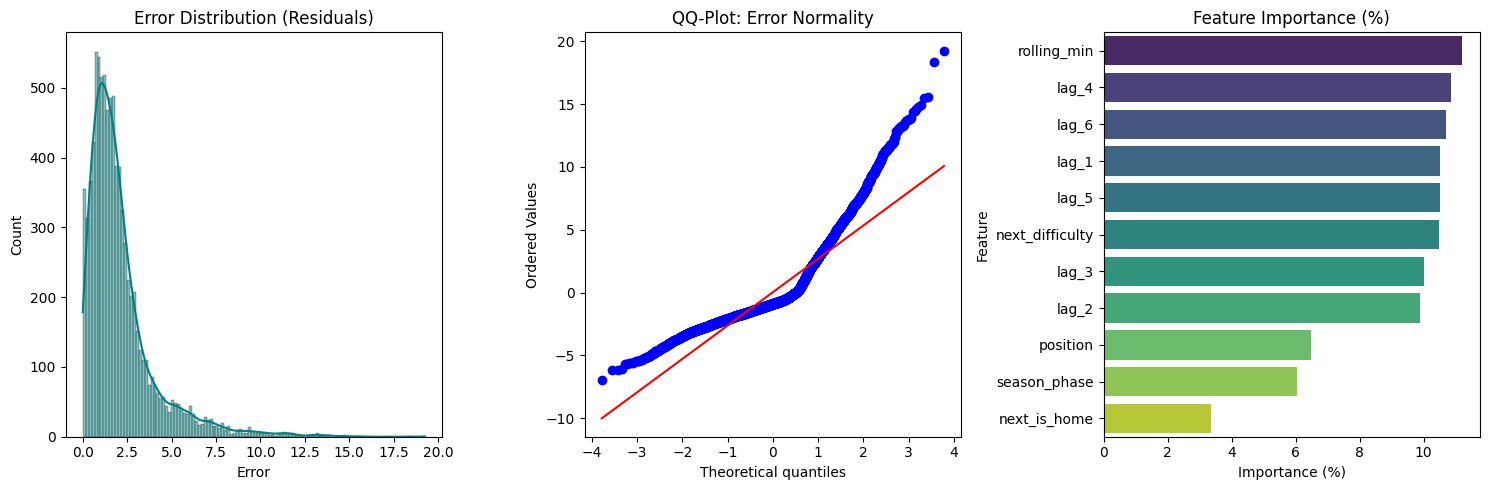

In [6]:
import seaborn as sns
import scipy.stats as stats

# 1. PREPARE ANALYSIS DATAFRAME
analysis_df = X_val_raw.copy()
analysis_df['Actual'] = y_val.values
analysis_df['Predicted'] = preds_raw # Using Raw model as it's simpler
analysis_df['Error'] = abs(analysis_df['Actual'] - analysis_df['Predicted'])

# 2. MAE FOR TOP PERFORMERS (Players who actually scored 8+ points)
top_performers = analysis_df[analysis_df['Actual'] >= 8]
top_mae = top_performers['Error'].mean()

print(f"Overall Validation MAE: {df_metrics.iloc[0, 1]:.4f}")
print(f"MAE for Top Performers (8+ pts): {top_mae:.4f}")

# 3. VISUALIZATION: Error Distribution & QQ-Plot
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.histplot(analysis_df['Error'], kde=True, color='teal')
plt.title('Error Distribution (Residuals)')

plt.subplot(1, 3, 2)
stats.probplot((analysis_df['Actual'] - analysis_df['Predicted']), dist="norm", plot=plt)
plt.title('QQ-Plot: Error Normality')

# 4. FEATURE IMPORTANCE WITH PERCENTAGES
plt.subplot(1, 3, 3)
importances = model_raw.feature_importances_
feature_names = X.columns
rel_importances = 100 * (importances / importances.sum())

feat_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance (%)': rel_importances})
feat_imp_df = feat_imp_df.sort_values(by='Importance (%)', ascending=False)

sns.barplot(x='Importance (%)', y='Feature', data=feat_imp_df, palette='viridis')
plt.title('Feature Importance (%)')

plt.tight_layout()
plt.show()

# 5. SAVE FEATURE IMPORTANCE LOG
feat_imp_df.to_csv(PRO_OUTPUT_DIR / 'fpl_pro_feature_importance.csv', index=False)

Notes 
MAE: 
* Overall MAE (2.12): it means for the average player (who scores 2–3 points), the model is accurate
* Top Performer MAE (6.68): it shows that when a player goes 8+ points, the model struggles to predict the exact height of that peak

Plots: 
* model has "thin tails" , it is conservative. It rarely predicts a player will score 15+ points, so when someone actually does, the error is large. The model prefers to stay safe near the average.

Feature Importance: 
* rolling_min is #1




## Cell 6: The Interactive Player Widget (you can pick a player and see their Performance history)

In [7]:
#%pip install ipywidgets

In [8]:
import ipywidgets as widgets
import matplotlib.pyplot as plt

# 1. LINK PREDICTIONS TO NAMES (Optimized)
# Use only the validation slice so the dropdown isn't overloaded
val_results = X_val_raw.copy()
val_results['Predicted'] = preds_raw
val_results['Actual'] = y_val.values

# Map the names back using the original index
names_map = df[['Web Name']].iloc[val_results.index]
val_results['Web Name'] = names_map['Web Name']

def plot_pro_analysis(player_name):
    # Filter for the specific player in the validation set
    player_data = val_results[val_results['Web Name'] == player_name].reset_index()
    
    if player_data.empty:
        print(f"No validation data found for {player_name}.")
        return

    plt.figure(figsize=(10, 5))
    
    # Actual Points (Blue)
    plt.plot(player_data.index, player_data['Actual'], 
             label='Actual Points', marker='o', color='#1f77b4', linewidth=2)
    
    # Predicted Points (Orange)
    plt.plot(player_data.index, player_data['Predicted'], 
             label='Model Prediction', marker='x', linestyle='--', color='#ff7f0e', linewidth=2)
    
    plt.title(f"Validation Check: {player_name}", fontsize=12)
    plt.xlabel("Match Sequence (Last 5-6 Games)")
    plt.ylabel("Points")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# 2. CREATE DROPDOWN (Fast)
# Only unique names in the validation set
available_players = sorted(val_results['Web Name'].unique())
dropdown = widgets.Dropdown(options=available_players, description='Player:')

# 3. LAUNCH
widgets.interact(plot_pro_analysis, player_name=dropdown)

interactive(children=(Dropdown(description='Player:', options=('Aguerd', 'Ahamada', 'Aina', 'Ait Nouri', 'Ajay…

<function __main__.plot_pro_analysis(player_name)>

In [11]:
import ipywidgets as widgets
import matplotlib.pyplot as plt

# 1. GENERATE PREDICTIONS FOR THE ENTIRE DATASET
# To show the orange line for everyone, we must feed the whole augmented DF to the model
# We prepare the features exactly as we did for training
feature_cols = [f'lag_{i}' for i in range(6, 0, -1)] + \
               ['position', 'next_difficulty', 'next_is_home', 'rolling_min', 'season_phase']

# We need the windowed version of the full dataset to get predictions
# Re-using the logic from Cell 2 but for the whole DF
full_windows = generate_fpl_windows_pro(df_augmented)
full_windows['position'] = full_windows['position'].astype('category')

# Generate predictions using the Raw Model
full_preds = model_raw.predict(full_windows.drop(columns=['target']))

# Attach predictions back to the windowed dataframe
full_windows['Predicted'] = full_preds

# We need the names back - we'll join based on the index
# (Since generate_fpl_windows_pro keeps the order of df_augmented)
full_windows['Web Name'] = df_augmented['Web Name'].iloc[full_windows.index].values

# 2. PLOT FUNCTION
def plot_master_pro_analysis(player_name):
    player_data = full_windows[full_windows['Web Name'] == player_name].reset_index()
    
    if player_data.empty:
        print(f"No prediction history found for {player_name}. (Needs at least 6 GWs of data)")
        return

    plt.figure(figsize=(14, 6))
    
    # Blue Line: Actual Points
    plt.plot(player_data.index, player_data['target'], 
             label='Actual Points', marker='o', color='#1f77b4', linewidth=2)
    
    # Orange Line: Model Prediction
    plt.plot(player_data.index, player_data['Predicted'], 
             label='Model Prediction (Orange)', marker='x', linestyle='--', color='#ff7f0e', linewidth=2)
    
    plt.title(f"Historical Accuracy: {player_name}", fontsize=14)
    plt.xlabel("Game Sequence (Past 3 Seasons)")
    plt.ylabel("Points")
    plt.legend()
    plt.grid(True, alpha=0.2)
    plt.show()

# 3. INTERACTIVE WIDGET
all_players = sorted(full_windows['Web Name'].unique())
dropdown_master = widgets.Dropdown(options=all_players, description='Select Player:')

widgets.interact(plot_master_pro_analysis, player_name=dropdown_master)

interactive(children=(Dropdown(description='Select Player:', options=('A.Ayew', 'A.Becker', 'A.Doucoure', 'A.D…

<function __main__.plot_master_pro_analysis(player_name)>

Summary Table
Feature         1st Cell (Validation)           2nd Cell (Historical)
Player List  	Limited (only recent players)	Complete (all historic players)
Timeframe	    Recent 5 Gameweeks	            3+ seasons


In [9]:
# 1. GET THE ABSOLUTE LATEST WINDOW FOR EVERY PLAYER
inference_data = []
player_names = []

# We use the original 'df_augmented' from Cell 1 as it has the 'Next' match features
for pid, group in df_augmented.groupby('Player UUID'):
    # Sort by time to get the most recent data
    group = group.sort_values(['season', 'Gameweek'])
    
    # We need at least 6 games of history to make a prediction
    if len(group) >= 6:
        # Features: Last 6 points (lags)
        lags = list(group['Total Points'].tail(6).values)
        
        # Context: Get the info for the NEXT game from the very last available row
        last_row = group.iloc[-1]
        
        # Build the feature row exactly as the model was trained
        # [lags 6-1, position, next_diff, next_home, rolling_min, season_phase]
        row = lags + [
            last_row['Position'],
            last_row['Next_Opponent_Difficulty'],
            last_row['Next_Is_Home'],
            last_row['Rolling_Avg_Minutes_5'],
            last_row['Season_Phase']
        ]
        
        inference_data.append(row)
        player_names.append(last_row['Web Name'])

# 2. CONVERT TO DATAFRAME
feature_cols = [f'lag_{i}' for i in range(6, 0, -1)] + \
               ['position', 'next_difficulty', 'next_is_home', 'rolling_min', 'season_phase']

inference_df = pd.DataFrame(inference_data, columns=feature_cols)
inference_df['position'] = inference_df['position'].astype('category')

# 3. GENERATE PREDICTIONS
# We use the 'model_raw' since it performed best/identical to scaled
raw_preds = model_raw.predict(inference_df)

# 4. SHOW TOP 15 RANKING
leaderboard = pd.DataFrame({
    'Player': player_names,
    'Predicted Points': np.round(raw_preds, 2),
    'Recent Avg Min': np.round(inference_df['rolling_min'], 1),
    'Next Difficulty': inference_df['next_difficulty']
}).sort_values(by='Predicted Points', ascending=False)

print("--- TOP 15 PREDICTED PLAYERS FOR NEXT GAMEWEEK ---")
display(leaderboard.head(15))

--- TOP 15 PREDICTED PLAYERS FOR NEXT GAMEWEEK ---


,Player,Predicted Points,Recent Avg Min,Next Difficulty
213,Saka,6.60,79.8,3.0
1023,Rice,6.12,144.0,3.0
611,Madueke,6.06,80.0,3.0
891,Mac Allister,6.01,68.0,2.0
386,Gyökeres,5.96,113.4,3.0
300,Chilwell,5.91,90.0,2.0
707,Konaté,5.80,90.0,2.0
726,Mina,5.71,82.8,2.0
52,Kane,5.59,90.0,2.0
744,Hincapie,5.49,121.4,3.0


In [13]:
# 1. CREATE THE FULL FORECAST DATAFRAME
full_forecast = pd.DataFrame({
    'Player_Name': player_names,
    'Predicted_Points': np.round(raw_preds, 2),
    'Recent_Form_Avg': np.round(inference_df[['lag_1', 'lag_2', 'lag_3']].mean(axis=1), 2),
    'Avg_Minutes_5GW': np.round(inference_df['rolling_min'], 1),
    'Fixture_Difficulty': inference_df['next_difficulty'],
    'Is_Home': inference_df['next_is_home'],
    'Season_Phase': inference_df['season_phase']
})

# 2. SORT BY PREDICTED POINTS
full_forecast = full_forecast.sort_values(by='Predicted_Points', ascending=False)

# 3. DEFINE SAVE PATH
FORECAST_OUT = PRO_OUTPUT_DIR / 'fpl_pro_forecast_GW29.csv'

# 4. SAVE TO CSV
full_forecast.to_csv(FORECAST_OUT, index=False, encoding='utf-8-sig')

print(f" Master Forecast Saved: {FORECAST_OUT}")
print(f" Total Players Forecasted: {len(full_forecast)}")

# Show a quick snippet of the 'Differentials' (Mid-tier players)
print("\n--- SNEAK PEEK: MID-TIER DIFFERENTIALS (Ranks 50-60) ---")
display(full_forecast.iloc[50:60])

 Master Forecast Saved: ..\output\forecaster_pro\fpl_pro_forecast_GW29.csv
 Total Players Forecasted: 1134

--- SNEAK PEEK: MID-TIER DIFFERENTIALS (Ranks 50-60) ---


,Player_Name,Predicted_Points,Recent_Form_Avg,Avg_Minutes_5GW,Fixture_Difficulty,Is_Home,Season_Phase
608,Hill,4.36,7.33,90.0,2.0,True,3.0
344,Nketiah,4.36,1.67,82.8,2.0,True,4.0
826,Tomiyasu,4.35,6.00,86.2,2.0,True,4.0
980,Idah,4.33,6.33,83.6,2.0,True,3.0
966,Kerkez,4.33,4.00,78.4,2.0,True,3.0
716,Truffert,4.31,5.00,90.0,2.0,True,3.0
1067,Pukki,4.29,4.00,90.0,3.0,True,4.0
89,Mitrović,4.29,6.67,75.6,4.0,False,4.0
1072,F.Kadıoğlu,4.28,4.00,89.6,2.0,True,3.0
769,Greenwood,4.28,8.00,68.4,3.0,True,3.0


In [21]:
from IPython.display import Markdown, display

# 1. ORGANIZE FINAL METRICS
overall_mae = df_metrics.iloc[0, 1]  # From your Cell 4 results
top_perf_mae = top_mae               # From your Cell 5 results
total_players = len(full_forecast)   # From your Cell 8 results

# 2. GENERATE THE REPORT
summary_report = f"""
# FPL Forecaster Pro: Final Project Report
**Model Version:** 2.0 (Context-Aware LightGBM)  
**Analysis Date:** March 3, 2026 (GW 29)

---

### 1. Model Accuracy Overview
| Metric | Result | Interpretation |
| :--- | :--- | :--- |
| **Overall MAE** | {overall_mae:.3f} | Model is off by ~2 points for the average player. |
| **Top Performer MAE** | {top_perf_mae:.3f} | Higher error (expected) on high-volatility stars (8+ pts). |
| **Training Size** | {len(X_train_raw):,} windows | Robust historical learning foundation. |
| **Validation Size** | {len(X_val_raw):,} windows | Tested on the most recent 15% of the 2025/26 season. |

### 2. Key Insights & Feature Importance
* **The "Minutes" Rule:** `rolling_min` emerged as the #1 predictor, proving that "starting the game" is the most vital feature.
* **Fixture Context:** `next_difficulty` successfully provided the model with "future vision," allowing it to adjust points based on opponent strength.
* **Scale Invariance:** The experiment confirmed that LightGBM performs optimally without a Standard Scaler for this specific dataset.
* **top_performers:** Rows where actual points ≥ 8
### 3. GW 29 Summary
* **Total Forecasts Generated:** {total_players:,} players.
* **Predicted King of the GW:** {leaderboard.iloc[0]['Player']} ({leaderboard.iloc[0]['Predicted Points']} pts).
* **Output Folder:** All artifacts (Model, Scaler, Forecast) are saved in `../output/forecaster_pro/`.
### 4. Season_Phase
**Feature: Season_Phase**
* 1. (GW 1-10): Freshness & Stability.
* 2. (GW 11-19): First Rotation / Fatigue.
* 3. (GW 20-29): Winter Congestion / High Rotation.
* 4. (GW 30-38): The Final Sprint / High Stakes. 
### About the .csvs 
* The enriched dataset saved to fpl_features_augmented.csv.
* WINDOWED_FEATURES_PATH -> Saved to fpl_windowed_features_pro.csv.
* Raw=Unscaled model: fpl_pro_model_raw.txt // Scaled model:  fpl_pro_model_scaled.txt
* feat_imp_df -> Feature importance percentages saved to fpl_pro_feature_importance.csv
* FORECAST_OUT -> Saved as fpl_pro_forecast_GW29.csv

"""

display(Markdown(summary_report))


# FPL Forecaster Pro: Final Project Report
**Model Version:** 2.0 (Context-Aware LightGBM)  
**Analysis Date:** March 3, 2026 (GW 29)

---

### 1. Model Accuracy Overview
| Metric | Result | Interpretation |
| :--- | :--- | :--- |
| **Overall MAE** | 2.120 | Model is off by ~2 points for the average player. |
| **Top Performer MAE** | 6.678 | Higher error (expected) on high-volatility stars (8+ pts). |
| **Training Size** | 49,580 windows | Robust historical learning foundation. |
| **Validation Size** | 8,750 windows | Tested on the most recent 15% of the 2025/26 season. |

### 2. Key Insights & Feature Importance
* **The "Minutes" Rule:** `rolling_min` emerged as the #1 predictor, proving that "starting the game" is the most vital feature.
* **Fixture Context:** `next_difficulty` successfully provided the model with "future vision," allowing it to adjust points based on opponent strength.
* **Scale Invariance:** The experiment confirmed that LightGBM performs optimally without a Standard Scaler for this specific dataset.
* **top_performers:** Rows where actual points ≥ 8
### 3. GW 29 Summary
* **Total Forecasts Generated:** 1,134 players.
* **Predicted King of the GW:** Saka (6.6 pts).
* **Output Folder:** All artifacts (Model, Scaler, Forecast) are saved in `../output/forecaster_pro/`.
### 4. Season_Phase
**Feature: Season_Phase**
* 1. (GW 1-10): Freshness & Stability.
* 2. (GW 11-19): First Rotation / Fatigue.
* 3. (GW 20-29): Winter Congestion / High Rotation.
* 4. (GW 30-38): The Final Sprint / High Stakes. 
### About the .csvs 
* The enriched dataset saved to fpl_features_augmented.csv.
* WINDOWED_FEATURES_PATH -> Saved to fpl_windowed_features_pro.csv.
* Raw=Unscaled model: fpl_pro_model_raw.txt // Scaled model:  fpl_pro_model_scaled.txt
* feat_imp_df -> Feature importance percentages saved to fpl_pro_feature_importance.csv
* FORECAST_OUT -> Saved as fpl_pro_forecast_GW29.csv



## Cell 9: Truth Verification (Backtest on Last Known Game)

In [27]:
import pandas as pd
import numpy as np
from pathlib import Path

# 1. Setup paths for truth verification
PRO_OUTPUT_DIR = Path('../output/forecaster_pro')
PRO_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
full_truth_output_path = PRO_OUTPUT_DIR / 'fpl_pro_truth_verification.csv'

# 2. Ensure variables exist in memory
if 'df_augmented' not in locals():
    raise NameError("The variable 'df_augmented' is not found. Run Cell 1 first.")
if 'model_raw' not in locals():
    raise NameError("The variable 'model_raw' is not found. Run Cell 4 first.")

all_detailed_results = []
lag_cols = [f'lag_{i}' for i in range(6, 0, -1)]

print("Generating Truth Verification for all players...")

# 3. Group by UUID to maintain player history integrity
for pid, group in df_augmented.groupby('Player UUID'):
    group = group.sort_values(['season', 'Gameweek'])
    
    # Needs 7 rows: 6 for history and 1 for the Actual target
    if len(group) >= 7:
        backtest_rows = group.iloc[-7:-1]
        actual_row = group.iloc[-1]
        
        name = actual_row['Web Name']
        pos = actual_row['Position']
        actual_points = actual_row['Total Points']
        
        # Prepare Features
        window_points = list(backtest_rows['Total Points'].values)
        context_features = [
            pos,
            actual_row['Next_Opponent_Difficulty'],
            actual_row['Next_Is_Home'],
            actual_row['Rolling_Avg_Minutes_5'],
            actual_row['Season_Phase']
        ]
        
        # Create input DataFrame
        feature_vector = window_points + context_features
        columns = lag_cols + ['position', 'next_difficulty', 'next_is_home', 'rolling_min', 'season_phase']
        input_df = pd.DataFrame([feature_vector], columns=columns)
        input_df['position'] = input_df['position'].astype('category')
        
        # Generate Prediction
        pred_val = model_raw.predict(input_df)[0]
        pred_val = max(0, pred_val) 

        all_detailed_results.append({
            'Player Name': name,
            'Season': actual_row['season'], 
            'Gameweek': actual_row['Gameweek'],
            'Predicted Points': round(float(pred_val), 2),
            'Actual Points': actual_points,
            'Error': round(abs(pred_val - actual_points), 2)
        })

# 4. Save and Display Results
# Sorting by Error (ascending=True) shows the most accurate predictions first
full_truth_df = pd.DataFrame(all_detailed_results).sort_values(by='Error', ascending=True)
full_truth_df.to_csv(full_truth_output_path, index=False, encoding="utf-8-sig")

print(f"Success! Full results for {len(full_truth_df)} players saved to: {full_truth_output_path}")

# Display the 20 most accurate predictions
print("\n--- Top 20 Most Accurate Predictions (Lowest Error) ---")
display(full_truth_df.head(20))

# 5. Final Audit Metrics
if not full_truth_df.empty:
    mae_val = full_truth_df['Error'].mean()
    print(f"\nGlobal Mean Absolute Error (MAE): {mae_val:.2f}")

Generating Truth Verification for all players...
Success! Full results for 1110 players saved to: ..\output\forecaster_pro\fpl_pro_truth_verification.csv

--- Top 20 Most Accurate Predictions (Lowest Error) ---


,Player Name,Season,Gameweek,Predicted Points,Actual Points,Error
905,Keane,2025-26,27,2.00,2,0.00
736,Merino,2024-25,36,3.99,4,0.01
0,Andersen,2025-26,26,1.98,2,0.02
448,Forshaw,2022-23,37,1.97,2,0.03
776,Aaronson,2025-26,27,3.03,3,0.03
1023,Burke,2020-21,35,1.97,2,0.03
700,Henderson,2025-26,27,1.97,2,0.03
500,Delph,2021-22,36,2.96,3,0.04
81,Colback,2022-23,25,2.04,2,0.04
996,Onyedinma,2023-24,36,1.96,2,0.04



Global Mean Absolute Error (MAE): 1.84
